
# Отчёт по лабораторной работе 1  
**Рудаков Максим, М3233**



## 1. Постановка задачи

Целью работы является исследование методов одномерной минимизации функции вида:

$$
f(x) \to \min, \quad x \in [a, b]
$$

Рассматриваются методы нулевого порядка, использующие только значения функции.

### Задачи:
- Реализовать методы оптимизации:
  - метод пассивного поиска  
  - метод дихотомии  
  - метод золотого сечения  
  - метод Фибоначчи  
  - метод парабол  
- Исследовать их работу на различных функциях  
- Сравнить методы  
- Сравнить с библиотечным методом Brent  
- Исследовать стратегию exploration + exploitation  



## 2. Модели задач

Рассмотрены функции:

- Хорошая: $f(x) = x^2$  
- Плато: $f(x) = x^8$  
- Асимметричная: $f(x) = x^2 + e^{5(1-x)}$  
- Мультимодальная: $f(x) = x^2 + \sin(5x)$  

Точности:

$$
\varepsilon \in \{10^{-1}, \dots, 10^{-8}\}
$$


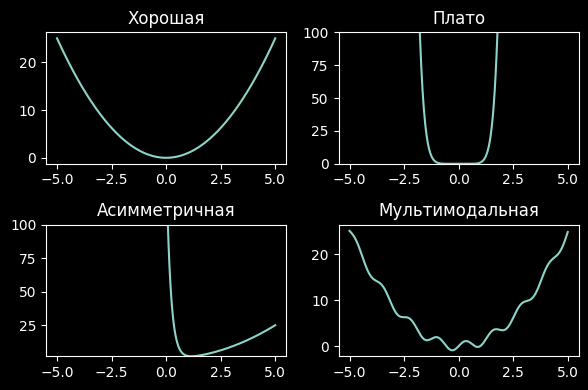

In [10]:
import numpy as np
import matplotlib.pyplot as plt

functions = {
    "Хорошая": lambda x: x ** 2,
    "Плато": lambda x: x ** 8,
    "Асимметричная": lambda x: x ** 2 + np.exp(5 * (1 - x)),
    "Мультимодальная": lambda x: x ** 2 + np.sin(5 * x)
}

x = np.linspace(-5, 5, 500)

plt.figure(figsize=(6, 4))

for i, (name, f) in enumerate(functions.items()):
    plt.subplot(2, 2, i + 1)
    y = f(x)
    if np.max(np.abs(y)) > 1e2:
        plt.ylim(np.min(y[y > -1e2]), 1e2)
    plt.plot(x, f(x))
    plt.title(name)

plt.tight_layout()
plt.show()


## 3. Запуск экспериментов


In [11]:
import shutil
import os

folder_path = 'results/'
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)
os.makedirs(folder_path)

In [12]:
from calculations import *

results = run_all()

## 4. Анализ результатов

In [13]:
import os
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#### Таблицы результативности методов

Выведем таблицы для каждой функции. Таблицы иллюстрируют, сколько итераций и вызовов потребовалось каждому методу для достижения требуемой точности.

Лимит количества вызовов был выставлен на 1e4.

In [14]:
for fname in sorted(os.listdir("results")):
    if fname.startswith("summary"):
        name = fname.lstrip("summary")[1:-4]
        print(f"\n=== {name} функция ===")
        display(pd.read_csv(os.path.join("results", fname)))


=== Ассиметричная функция ===


,method,iterations,calls,eps
0,brent,17.0,20.0,1.000000e-08
1,Метод Фибоначчи,42.0,44.0,1.000000e-08
2,Метод золотого сечения,43.0,45.0,1.000000e-08
3,Exploration & exploitation,25.0,46.0,1.000000e-08
4,Метод дихотомии,30.0,60.0,1.000000e-08
5,Метод пассивного поиска,1.0,1000.0,1.000000e-08
6,Метод парабол,10000.0,10003.0,1.000000e-08



=== Мультимодальная функция ===


,method,iterations,calls,eps
0,Метод парабол,11.0,14.0,1.000000e-08
1,brent,16.0,19.0,1.000000e-08
2,Метод Фибоначчи,42.0,44.0,1.000000e-08
3,Метод золотого сечения,43.0,45.0,1.000000e-08
4,Exploration & exploitation,25.0,46.0,1.000000e-08
5,Метод дихотомии,30.0,60.0,1.000000e-08
6,Метод пассивного поиска,1.0,1000.0,1.000000e-08



=== Плато функция ===


,method,iterations,calls,eps
0,Метод парабол,16.0,19.0,1.000000e-08
1,brent,18.0,21.0,1.000000e-08
2,Метод Фибоначчи,42.0,44.0,1.000000e-08
3,Метод золотого сечения,43.0,45.0,1.000000e-08
4,Exploration & exploitation,25.0,46.0,1.000000e-08
5,Метод дихотомии,30.0,60.0,1.000000e-08
6,Метод пассивного поиска,1.0,1000.0,1.000000e-08



=== Хорошая функция ===


,method,iterations,calls,eps
0,Метод парабол,3.0,5.0,1.000000e-08
1,brent,5.0,8.0,1.000000e-08
2,Метод Фибоначчи,42.0,44.0,1.000000e-08
3,Метод золотого сечения,43.0,45.0,1.000000e-08
4,Exploration & exploitation,25.0,46.0,1.000000e-08
5,Метод дихотомии,30.0,60.0,1.000000e-08
6,Метод пассивного поиска,1.0,1000.0,1.000000e-08


Из интересного, для Асимметричной функции (1 таблица) метод парабол не сработал, то есть спустя 1е4 вызовов он не приблизился к требуемой точности. Функция была подобрана так специально.

#### Графики затрат к сходимости

Графики иллюстрируют изменение кол-ва итераций и вызовов в зависимости от приближения для разных функций.
Графики сгруппированы по методу.

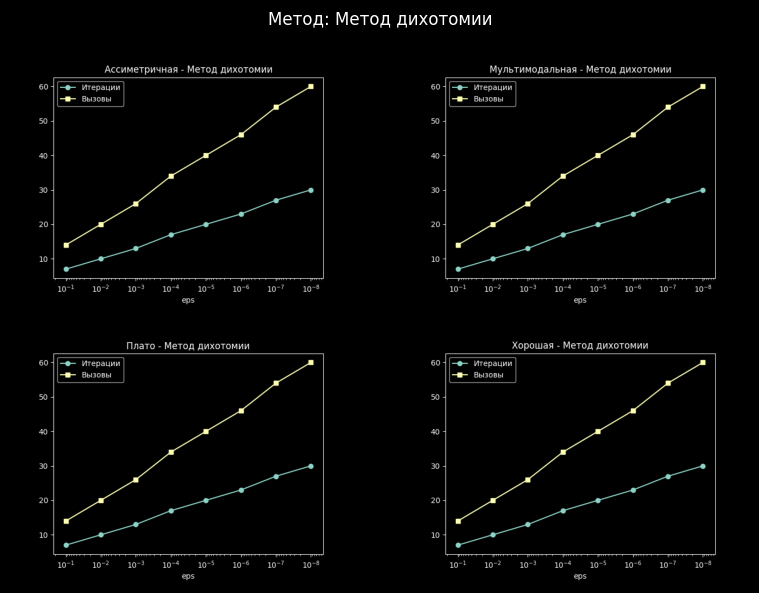

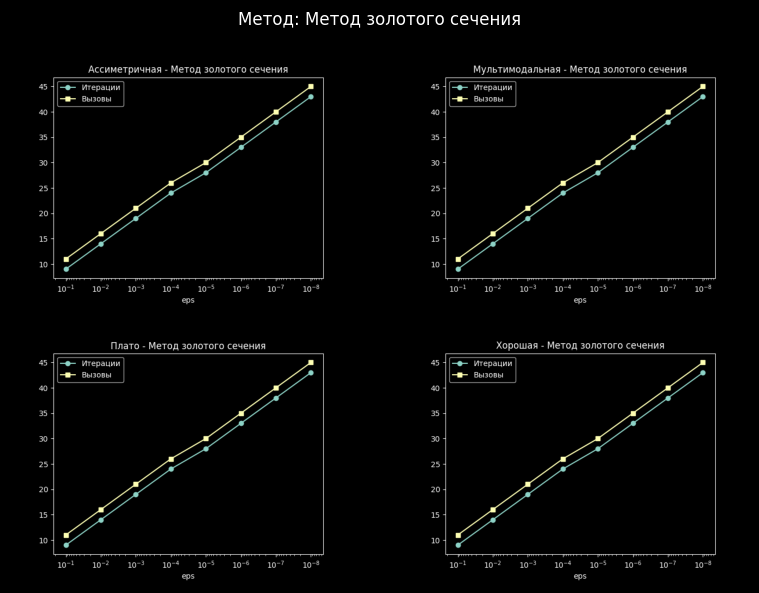

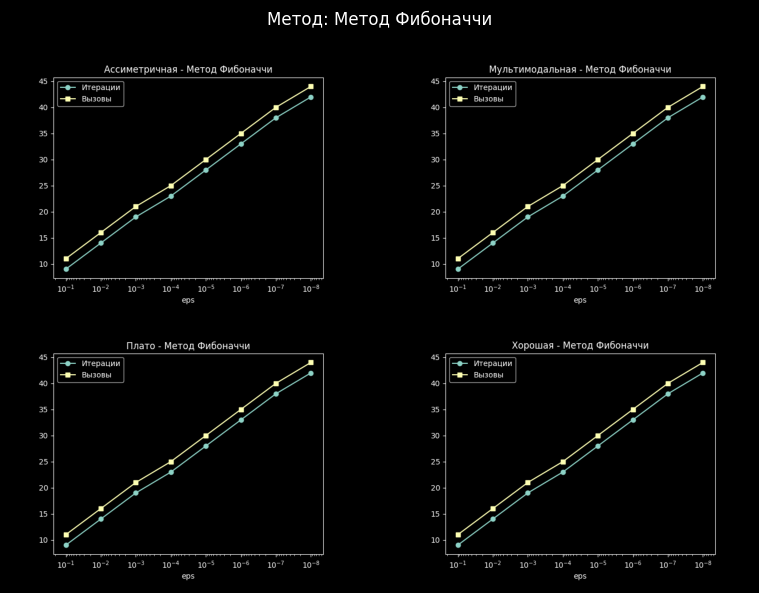

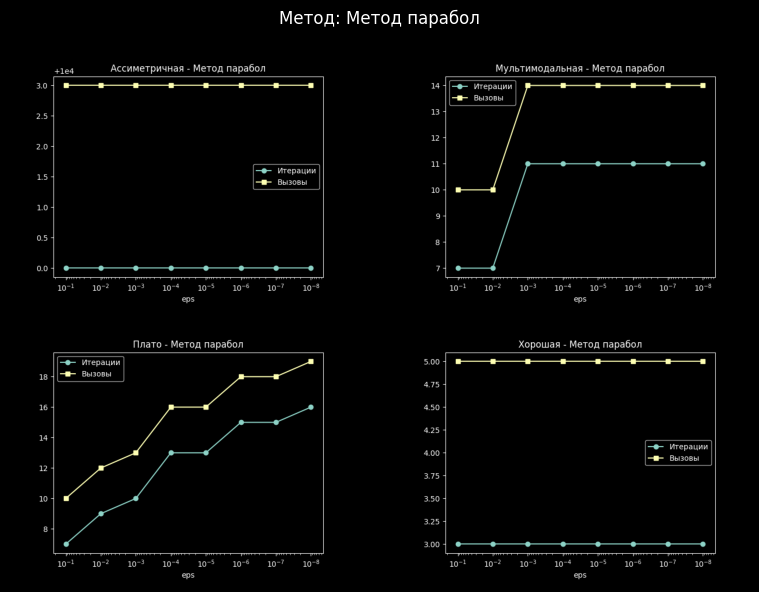

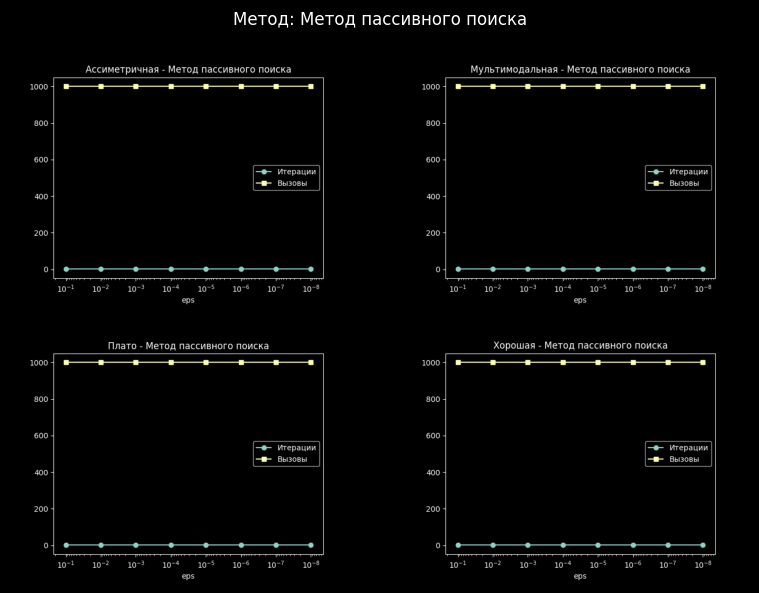

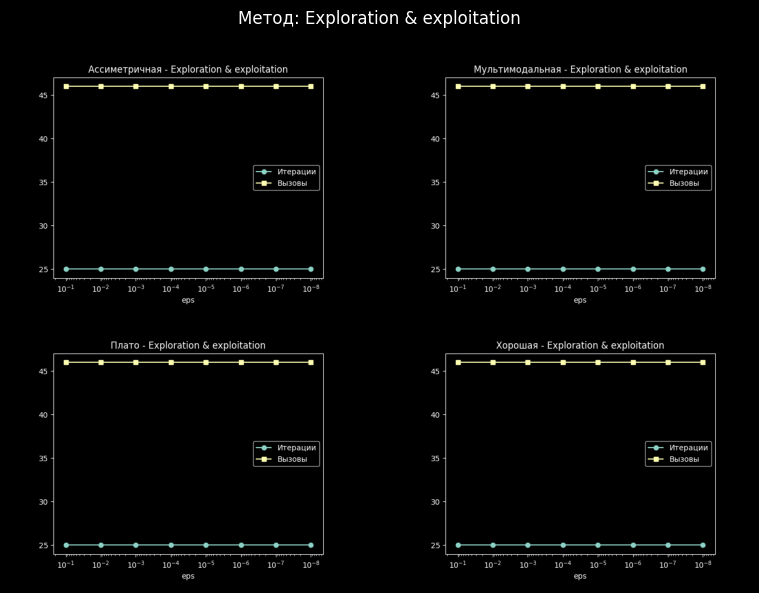

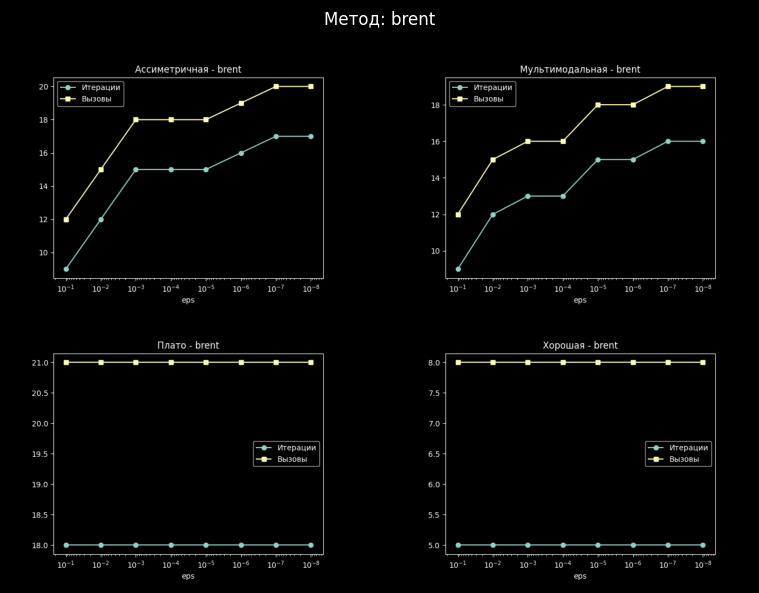

In [15]:
files = sorted(os.listdir("results"))

for method in METHODS:
    plt.figure(figsize=(8, 6))

    i = 1
    for f in files:
        if "metrics" in f and f.endswith(f"{method}.png"):
            img = mpimg.imread(os.path.join("results", f))

            plt.subplot(2, 2, i)
            plt.imshow(img)
            plt.axis('off')

            i += 1

    plt.suptitle(f"Метод: {method}")
    plt.tight_layout()
    plt.show()

Можно заметить, что, например, у метода brent присутсвуют строго горизонтальные отрезки, что указывает на то, что метод нашел сразу ответ с более близким приближением, "перескачив" через одно.

Добавить нечего, графики получились не особо показательные, можно не разглядывать, но я решил, что не лишне вставить. Далее будут графики сравнения, они чуть интереснее.

#### Динамика интервалов

В методе массивного поиска об интервале не может быть речи по его устройству, а из метода brent вытащить интервалы не получилось.

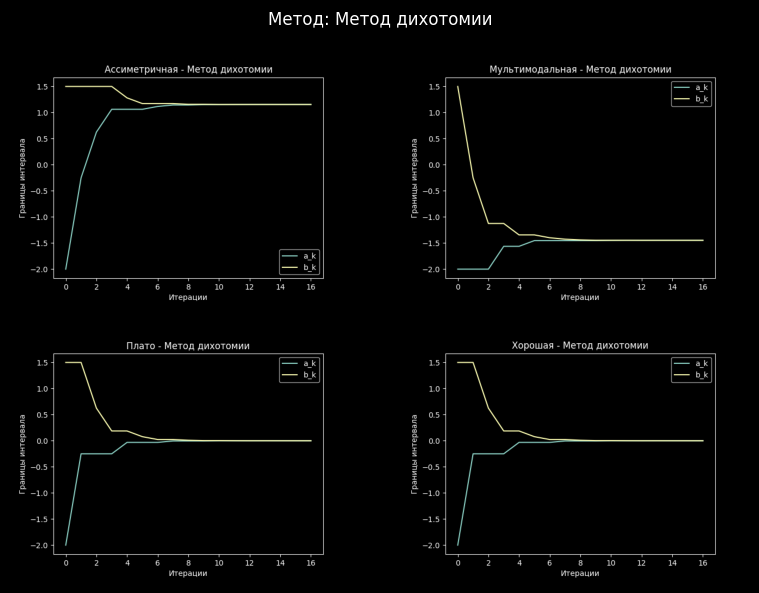

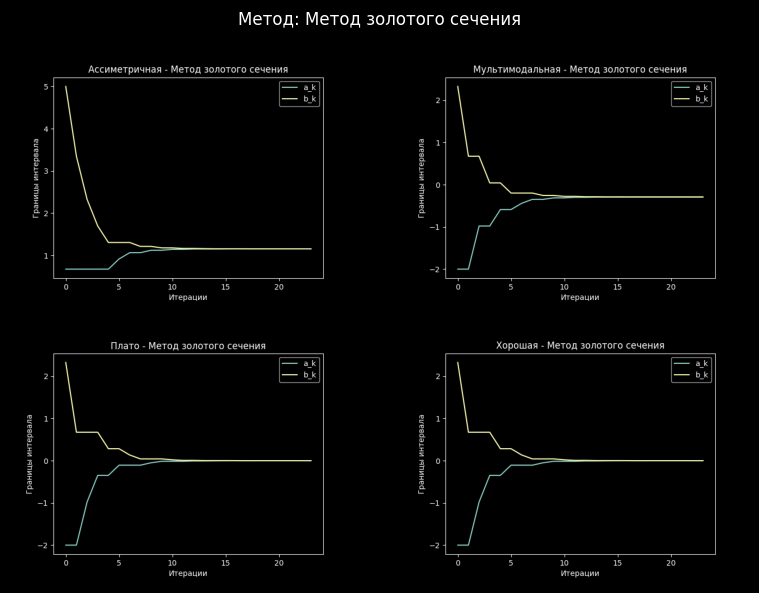

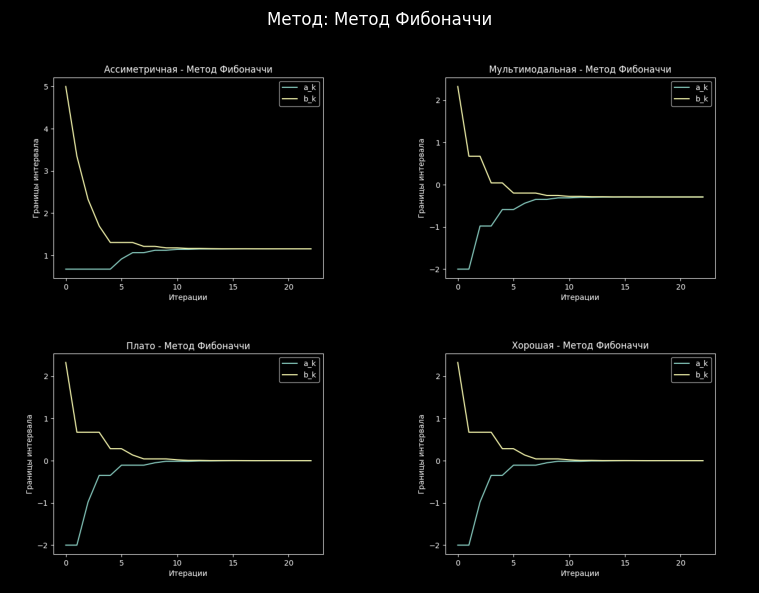

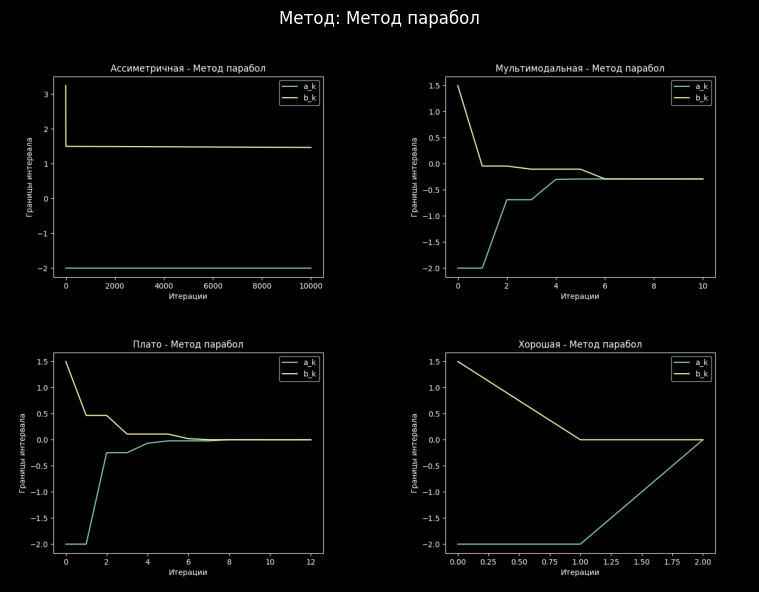

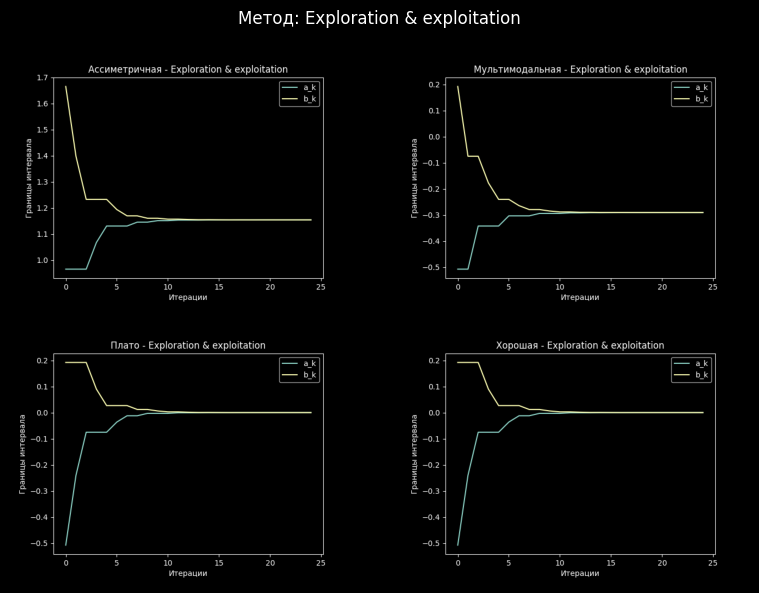

<Figure size 800x600 with 0 Axes>

In [16]:
files = sorted(os.listdir("results"))

for method in METHODS:
    if method == PASSIVE_SEARCH:
        continue

    plt.figure(figsize=(8, 6))

    i = 1
    for f in files:
        if "interval_" in f and "compare" not in f and f.endswith(f"{method}.png"):
            img = mpimg.imread(os.path.join("results", f))

            plt.subplot(2, 2, i)
            plt.imshow(img)
            plt.axis('off')

            i += 1

    plt.suptitle(f"Метод: {method}")
    plt.tight_layout()
    plt.show()

Наблюдение:
- интервалы сужаются монотонно
- скорость зависит от метода и функции
- интересно, что метод парабол справился с параболой ровно за 2 итерации и 1 вызов. Видимо, работает правильно.

#### Сравнение методов

Графики динамики длины интервалов на одном холсте.

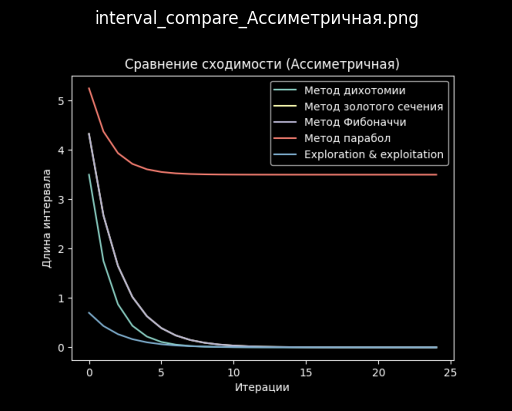

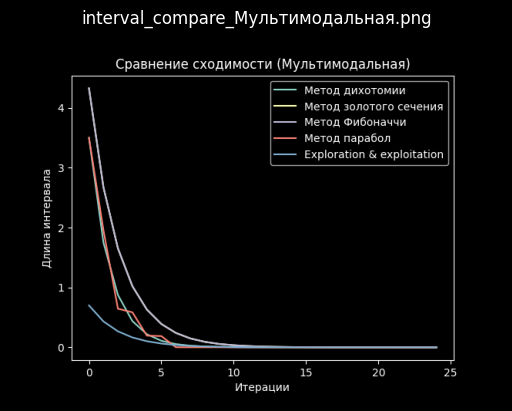

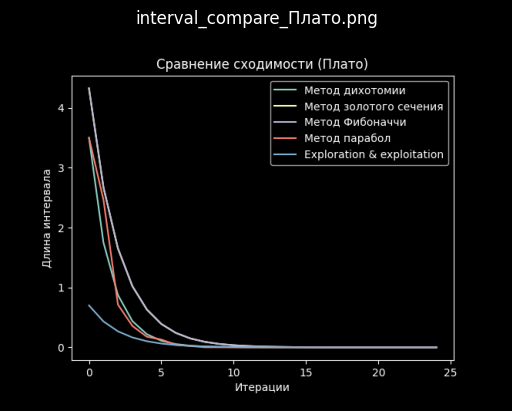

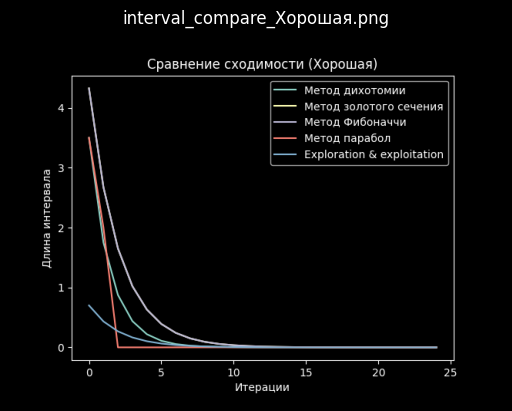

In [17]:
for fname in sorted(os.listdir("results")):
    if "interval_compare" in fname:
        img = mpimg.imread(os.path.join("results", fname))
        plt.imshow(img)
        plt.axis('off')
        plt.title(fname)
        plt.show()

Так как графики сделаны по количеству итераций, метод E&E выбивается вперед со старта. Конечно же, на практике под первой (или нулевой даже) итерацией подразумевается метод пассивного поиска (здесь 200 точек).

## 5. Вывод

В ходе работы были реализованы и исследованы методы одномерной оптимизации нулевого порядка: метод пассивного поиска, дихотомии, золотого сечения, Фибоначчи, парабол, exploration & exploitation, а также выполнено сравнение с методом Brent.

#### Основные результаты

* **Метод Brent** показал хорошие результаты по числу итераций и вызовов на всех функциях, что ожидаемо для популярного и оптимизированного умными людьми метода.
* **Метод парабол** очень эффективен на гладких функциях (например, $x^2$), но может не сходиться на сложных (асимметричных).
* **Методы Фибоначчи и золотого сечения** работают стабильно и предсказуемо, но медленнее.
* **Метод дихотомии** уступает по числу вызовов функции.
* **Пассивный поиск** неэффективен из-за большого числа вызовов.
* **Exploration & exploitation** -- компромисс: больше вызовов, меньше итераций.

#### Влияние функции

* Гладкие функции -> быстры интерполяционные методы
* Плато -> замедление всех методов
* Асимметрия -> возможна потеря сходимости (параболы)
* Мультимодальность -> важна устойчивость метода

На практике лучше всё же, если придется, использовать метод brent, а не изобретать велосипед. Остальные методы либо медленнее, либо чувствительны к свойствам функции.
